# POO
## Movimiento Mecánico

Análisar el tipo de órbita de una partícula que se mueve bajo la acción de una fuerza:
$$
F(r)=-\frac{K}{r^2} \hat{a_r}
$$





Mediante la ecuación:
$$ 
\frac{d^2z}{d\psi^2} + z = -\frac{\mu}{L^2} \cdot \frac{1}{z^2} \cdot f\left(\frac{1}{z}\right)
$$
La cual nos permite encontrar el tipo de órbita si se conoce la fuerza o viceversa, para: $$ z=\dfrac{1}{r}$$ Resulta:
$$ 
\frac{d^2z}{d\psi^2} + z = \frac{\mu K}{L^2} 
$$
Tenemos una ecuación diferencial ordinaria no homogénea para una variable "z" en evolución de una variable angular $ \psi $ la cual se conoce como la ecuación de Binet que describe la trayectoria en coordenadas polares.

## Uso del método Runge_Kutta  de 4to orden



In [1]:
class RungeKutta:
    def __init__(self, system, h):
        """Inicializa la clase RungeKutta."""
        self.system = system
        self.h = h

    def step(self, t, y, h=None):
        """Realiza un solo paso del método de Runge-Kutta de cuarto orden."""
        if h is None:
            h = self.h  # Usa h de la instancia si no se proporciona uno específico
        
        k1 = self.system(t, y)
        k2 = self.system(t + h/2, [y[i] + h/2 * k1[i] for i in range(len(y))])
        k3 = self.system(t + h/2, [y[i] + h/2 * k2[i] for i in range(len(y))])
        k4 = self.system(t + h, [y[i] + h * k3[i] for i in range(len(y))])

        return [y[i] + (h/6) * (k1[i] + 2*k2[i] + 2*k3[i] + k4[i]) for i in range(len(y))]

    def solve(self, t_span, y0):
        """Resuelve el sistema de ecuaciones diferenciales usando Runge-Kutta."""
        t_start, t_end = t_span
        num_steps = int((t_end - t_start) / self.h) + 1  # Cantidad de pasos
        t_values = [t_start + i * self.h for i in range(num_steps)]  # Lista de tiempos predefinida
        y_values = [y0]

        y = y0[:]  # Copia de las condiciones iniciales

        for i in range(1, num_steps):
            if t_values[i] > t_end:  # Ajustar último paso si es necesario
                h_last = t_end - t_values[i-1]
                y = self.step(t_values[i-1], y, h_last)
                t_values[i] = t_end
            else:
                y = self.step(t_values[i-1], y)
            
            y_values.append(y[:])  # Evitar mutabilidad

        return t_values, y_values

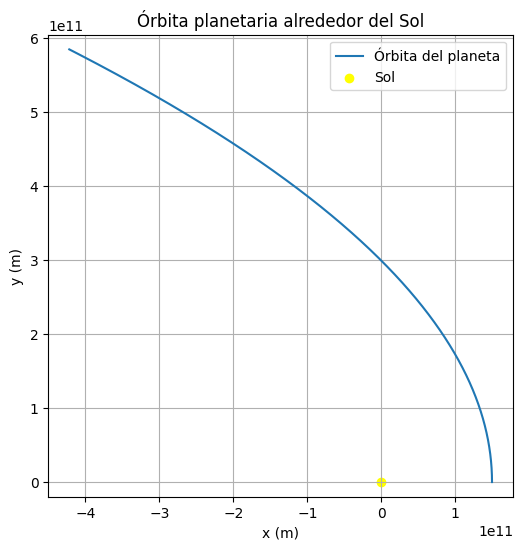

In [2]:
import matplotlib.pyplot as plt
import math

# Constantes físicas
G = 6.674e-11  # Constante gravitacional en m^3/kg/s^2
M_sun = 1.989e30  # Masa del Sol en kg

# Definir las ecuaciones diferenciales
def dr_dt(vr):
    return vr

def dvr_dt(r, vr, vtheta):
    return - (G * M_sun) / (r ** 2) + r * vtheta ** 2

def dtheta_dt(vtheta):
    return vtheta

def dvtheta_dt(r, vr, vtheta):
    return - (2 * vr * vtheta) / r

# Método de Runge-Kutta para resolver las ecuaciones
def runge_kutta_orbita(r0, vr0, theta0, vtheta0, t_max, h):
    N = int(t_max / h)  # Número de pasos

    # Inicializar listas de resultados
    r_values, vr_values, theta_values, vtheta_values = [r0], [vr0], [theta0], [vtheta0]
    time_values = [0]

    r, vr, theta, vtheta = r0, vr0, theta0, vtheta0  # Variables iniciales

    for _ in range(N):
        t = time_values[-1]

        # Runge-Kutta 4to orden
        k1_r = h * dr_dt(vr)
        k1_vr = h * dvr_dt(r, vr, vtheta)
        k1_theta = h * dtheta_dt(vtheta)
        k1_vtheta = h * dvtheta_dt(r, vr, vtheta)

        k2_r = h * dr_dt(vr + k1_vr / 2)
        k2_vr = h * dvr_dt(r + k1_r / 2, vr + k1_vr / 2, vtheta + k1_vtheta / 2)
        k2_theta = h * dtheta_dt(vtheta + k1_vtheta / 2)
        k2_vtheta = h * dvtheta_dt(r + k1_r / 2, vr + k1_vr / 2, vtheta + k1_vtheta / 2)

        k3_r = h * dr_dt(vr + k2_vr / 2)
        k3_vr = h * dvr_dt(r + k2_r / 2, vr + k2_vr / 2, vtheta + k2_vtheta / 2)
        k3_theta = h * dtheta_dt(vtheta + k2_vtheta / 2)
        k3_vtheta = h * dvtheta_dt(r + k2_r / 2, vr + k2_vr / 2, vtheta + k2_vtheta / 2)

        k4_r = h * dr_dt(vr + k3_vr)
        k4_vr = h * dvr_dt(r + k3_r, vr + k3_vr, vtheta + k3_vtheta)
        k4_theta = h * dtheta_dt(vtheta + k3_vtheta)
        k4_vtheta = h * dvtheta_dt(r + k3_r, vr + k3_vr, vtheta + k3_vtheta)

        r += (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6
        vr += (k1_vr + 2*k2_vr + 2*k3_vr + k4_vr) / 6
        theta += (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta) / 6
        vtheta += (k1_vtheta + 2*k2_vtheta + 2*k3_vtheta + k4_vtheta) / 6

        # Guardar valores
        r_values.append(r)
        vr_values.append(vr)
        theta_values.append(theta)
        vtheta_values.append(vtheta)
        time_values.append(t + h)

    return r_values, theta_values

# Parámetros iniciales para la órbita de la Tierra alrededor del Sol
r0 = 1.496e11  # Distancia inicial (radio orbital medio) en metros
vr0 = 0  # Velocidad radial inicial en m/s
theta0 = 0  # Ángulo inicial en radianes

# Velocidades orbitales
v_circular = math.sqrt(G * M_sun / r0)  # Velocidad para órbita circular
v_escape = math.sqrt(2 * G * M_sun / r0)  # Velocidad de escape

#  PRUEBA DIFERENTES ÓRBITAS:
#vtheta0 = (0.9 * v_circular) / r0  # Órbita elíptica cerrada
#vtheta0 = (1.1 * v_circular) / r0  # Órbita elíptica más grande
vtheta0 = (1.0 * v_escape) / r0  # Órbita parabólica (escape)
# vtheta0 = (1.2 * v_escape) / r0  # Órbita hiperbólica (escape con velocidad extra)

t_max = 3.154e7  # Un año en segundos
h = 1000  # Paso de integración en segundos

# Ejecutar Runge-Kutta
r_values, theta_values = runge_kutta_orbita(r0, vr0, theta0, vtheta0, t_max, h)

# Convertir coordenadas polares a cartesianas para graficar
x_values = [r * math.cos(theta) for r, theta in zip(r_values, theta_values)]
y_values = [r * math.sin(theta) for r, theta in zip(r_values, theta_values)]

# Graficar la órbita
plt.figure(figsize=(6,6))
plt.plot(x_values, y_values, label="Órbita del planeta")
plt.scatter([0], [0], color='yellow', label="Sol")  # Representa el Sol en el centro
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Órbita planetaria alrededor del Sol")
plt.legend()
plt.grid()
plt.axis("equal")  # Mantiene la escala 1:1
plt.show()



In [7]:
import math
import time
from functools import lru_cache
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from abc import ABC, abstractmethod

In [8]:
""""En el sigiente codigo orientado a objetos (leyes de Kepler) implementaremos encapsulamiento, decoradores
    un método numerico (Runge-kutta) para determinar las orbitas de un sistema de dos cuerpos"""

def f(psi, r, dr_dpsi, mu):
    """ Sistema de ecuaciones diferenciales basado en la ley de Kepler """
    dr2_dpsi2 = (mu / (r**2)) - r
    return [dr_dpsi, dr2_dpsi2]  # Devolvemos una lista en lugar de np.array

def runge_kutta_4(r_0, dr_dpsi_0, psi_end, step_size, mu):
    psi_values = [0]
    r_values = [r_0]
    dr_values = [dr_dpsi_0]
    
    psi = 0
    r = r_0
    dr_dpsi = dr_dpsi_0
    
    while psi < psi_end:
        # Calculamos los incrementos de Runge-Kutta
        k1 = [step_size * v for v in f(psi, r, dr_dpsi, mu)]
        k2 = [step_size * v for v in f(psi + 0.5 * step_size, r + 0.5 * k1[0], dr_dpsi + 0.5 * k1[1], mu)]
        k3 = [step_size * v for v in f(psi + 0.5 * step_size, r + 0.5 * k2[0], dr_dpsi + 0.5 * k2[1], mu)]
        k4 = [step_size * v for v in f(psi + step_size, r + k3[0], dr_dpsi + k3[1], mu)]
        
        # Promediamos para actualizar r y dr/dpsi
        r += (k1[0] + 2*k2[0] + 2*k3[0] + k4[0]) / 6
        dr_dpsi += (k1[1] + 2*k2[1] + 2*k3[1] + k4[1]) / 6
        psi += step_size
        
        # Guardamos valores
        psi_values.append(psi)
        r_values.append(r)
        dr_values.append(dr_dpsi)
    
    return psi_values, r_values

In [9]:
class CuerpoCeleste(ABC):
    def __init__(self, masa, x, y, vx, vy):
        self._masa = masa
        self._x = x
        self._y = y
        self._vx = vx
        self._vy = vy
        self.trayectoria = []  # Lista para almacenar la trayectoria

    @property
    def masa(self):
        return self._masa

    @property
    def posicion(self):
        return self._x, self._y

    @property
    def velocidad(self):
        return self._vx, self._vy

    @abstractmethod
    def actualizar_posicion(self):
        pass

    def agregar_trayectoria(self):
        """Almacena la posición actual en la trayectoria."""
        self.trayectoria.append((self._x, self._y))


class Planeta(CuerpoCeleste):
    def __init__(self, masa, x, y, vx, vy, mu):
        super().__init__(masa, x, y, vx, vy)
        self.mu = mu  # Parámetro gravitacional estándar

    @lru_cache(maxsize=None)
    def calcular_orbita(self, r_0, dr_dpsi_0, psi_end, step_size):
        """
        Utiliza el método numérico de Runge-Kutta para calcular la órbita.
        """
        psi_values, r_values = runge_kutta_4(r_0, dr_dpsi_0, psi_end, step_size, self.mu)
        return psi_values, r_values

    def actualizar_posicion(self, r_0, dr_dpsi_0, psi_end, step_size):
        """
        Calcula la órbita y actualiza la posición del planeta en cada paso.
        """
        psi_values, r_values = self.calcular_orbita(r_0, dr_dpsi_0, psi_end, step_size)
        
        # Convertir (r, psi) a coordenadas cartesianas (x, y) y almacenarlas
        for psi, r in zip(psi_values, r_values):
            self._x = r * math.cos(psi)
            self._y = r * math.sin(psi)
            self.agregar_trayectoria()  # Guardamos la trayectoria

## simulación

In [10]:
# Crear un planeta con condiciones iniciales
planeta = Planeta(masa=5.97e24, x=0, y=1, vx=0, vy=1, mu=1.0)

# Condiciones iniciales
r_0 = 1.0  # Radio inicial
dr_dpsi_0 = 0.0  # Velocidad radial inicial
psi_end = 2 * math.pi  # Orbita completa
step_size = 0.01  # Paso de integración

# Ejecutar la simulación
planeta.actualizar_posicion(r_0, dr_dpsi_0, psi_end, step_size)

# Ver la trayectoria calculada
print(planeta.trayectoria)


[(1.0, 0.0), (0.9999500004166653, 0.009999833334166664), (0.9998000066665778, 0.01999866669333308), (0.9995500337489875, 0.02999550020249566), (0.9992001066609779, 0.03998933418663416), (0.9987502603949663, 0.04997916927067833), (0.9982005399352042, 0.0599640064794446), (0.9975510002532796, 0.06994284733753277), (0.9968017063026194, 0.0799146939691727), (0.9959527330119943, 0.08987854919801104), (0.9950041652780258, 0.09983341664682814), (0.9939560979566968, 0.1097783008371748), (0.9928086358538663, 0.11971220728891935), (0.9915618937147881, 0.12963414261969483), (0.9902159962126372, 0.13954311464423647), (0.9887710779360422, 0.14943813247359922), (0.9872272833756269, 0.15931820661424598), (0.9855847669095608, 0.16918234906699603), (0.9838436927881214, 0.1790295734258242), (0.9820042351172703, 0.1888588949765006), (0.9800665778412416, 0.19866933079506124), (0.9780309147241483, 0.2084598998460996), (0.9758974493306055, 0.21822962308086938), (0.9736663950053748, 0.22797752353518846), (0.

In [18]:
class Planeta(CuerpoCeleste):
    def __init__(self, masa, x, y, vx, vy, mu):
        super().__init__(masa, x, y, vx, vy)
        self.mu = mu  # Parámetro gravitacional estándar

    @lru_cache(maxsize=None)
    def calcular_orbita(self, r_0, dr_dpsi_0, psi_end, step_size):
        """
        Utiliza el método numérico de Runge-Kutta para calcular la órbita.
        """
        psi_values, r_values = runge_kutta_4(r_0, dr_dpsi_0, psi_end, step_size, self.mu)
        return psi_values, r_values

    def actualizar_posicion(self, r_0, dr_dpsi_0, psi_end, step_size):
        """
        Calcula la órbita y actualiza la posición del planeta en cada paso.
        """
        psi_values, r_values = self.calcular_orbita(r_0, dr_dpsi_0, psi_end, step_size)
        
        # Convertir (r, psi) a coordenadas cartesianas (x, y) y almacenarlas
        for psi, r in zip(psi_values, r_values):
            self._x = r * math.cos(psi)
            self._y = r * math.sin(psi)
            self.agregar_trayectoria()  # Guardamos la trayectoria

    def graficar_trayectoria(self):
        """
        Grafica la trayectoria orbital almacenada.
        """
        if not self.trayectoria:
            print("No hay datos en la trayectoria. Asegúrate de ejecutar actualizar_posicion() antes de graficar.")
            return

        # Extraer coordenadas X, Y de la trayectoria
        x_vals, y_vals = zip(*self.trayectoria)

        plt.figure(figsize=(6, 6))
        plt.plot(x_vals, y_vals, label="Órbita del planeta", color="b")
        plt.scatter([0], [0], color="r", marker="o", label="Cuerpo central (estrella)")  # Posición de la estrella
        plt.xlabel("Posición X (UA)")
        plt.ylabel("Posición Y (UA)")
        plt.title("Trayectoria Orbital del Planeta")
        plt.legend()
        plt.grid()
        plt.axis("equal")  # Mantiene la escala 1:1
        plt.show()


In [19]:
# Decorador para medir el tiempo de ejecución
def timing(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"Tiempo de ejecución de {func.__name__}: {end_time - start_time:.4f} segundos")
        return result
    return wrapper


In [20]:
def animar_orbita(planeta, alpha, psi_range):
    fig, ax = plt.subplots()
    ax.set_xlim(-1.5 * alpha, 1.5 * alpha)
    ax.set_ylim(-1.5 * alpha, 1.5 * alpha)
    ax.set_xlabel("Posición X")
    ax.set_ylabel("Posición Y")
    ax.set_title(f"Órbita del Planeta con excentricidad {planeta.epsilon}")

    # Inicializamos el gráfico de la órbita
    line, = ax.plot([], [], lw=2, label="Trayectoria")
    point, = ax.plot([], [], 'ro', label="Planeta")

    # Actualización de la animación
    def init():
        line.set_data([], [])
        point.set_data([], [])
        return line, point

    def update(frame):
        # Actualizar la posición del planeta
        planeta.actualizar_posicion(alpha, psi_range[frame])
        
        # Actualizar la trayectoria y el punto
        x_data = [p[0] for p in planeta.trayectoria]
        y_data = [p[1] for p in planeta.trayectoria]
        
        line.set_data(x_data, y_data)
        point.set_data(x_data[-1], y_data[-1])
        return line, point

    # Crear la animación
    ani = FuncAnimation(fig, update, frames=len(psi_range), init_func=init, blit=True, interval=50)

    plt.legend()
    plt.show()


In [13]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# Crear un objeto de la clase Planeta
planeta = Planeta(masa=5.97e24, x=1.0, y=0.0, vx=0.0, vy=29.78, epsilon=0.0167)

# Rango de ángulo psi para la simulación (de 0 a 360 grados)
psi_range = [i * math.pi / 180 for i in range(0, 360)]  # Psi de 0 a 360 grados

# Simular la órbita y mostrar la animación
animar_orbita(planeta, alpha=1.496e11, psi_range=psi_range)


TypeError: Planeta.__init__() got an unexpected keyword argument 'epsilon'

In [ ]:
# Crear un objeto de la clase Planeta
planeta = Planeta(masa=5.97e24, x=1.0, y=0.0, vx=0.0, vy=29.78, epsilon=0.0167)

# Rango de ángulo psi para la simulación
psi_range = [i * math.pi / 180 for i in range(0, 360)]  # Psi de 0 a 360 grados

# Simular la órbita y mostrar la visualización
simular_orbita(planeta, alpha=1.496e11, psi_range=psi_range)


NameError: name 'simular_orbita' is not defined

C:\Users\yonav\AppData\Local\Temp\ipykernel_18836\530699534.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


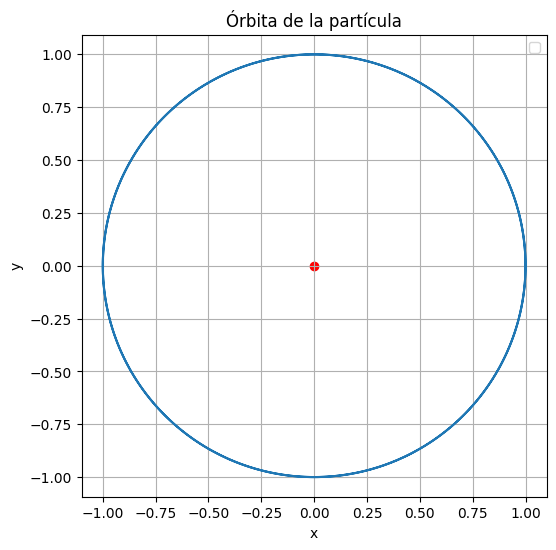

In [ ]:
import matplotlib.pyplot as plt
import math

def f1(theta, u, v, m, K, L):
    """ du/dtheta = v """
    return v

def f2(theta, u, v, m, K, L):
    """ dv/dtheta = m*K/L^2 - u """
    return (m * K) / (L ** 2) - u

def runge_kutta(h, theta_max, u0, v0, m, K, L):
    """ Implementa RK4 para resolver la ecuación de la órbita """
    theta = 0
    u = u0
    v = v0
    
    theta_vals = [theta]
    u_vals = [u]
    
    while theta < theta_max:
        k1_u = h * f1(theta, u, v, m, K, L)
        k1_v = h * f2(theta, u, v, m, K, L)
        
        k2_u = h * f1(theta + h/2, u + k1_u/2, v + k1_v/2, m, K, L)
        k2_v = h * f2(theta + h/2, u + k1_u/2, v + k1_v/2, m, K, L)
        
        k3_u = h * f1(theta + h/2, u + k2_u/2, v + k2_v/2, m, K, L)
        k3_v = h * f2(theta + h/2, u + k2_u/2, v + k2_v/2, m, K, L)
        
        k4_u = h * f1(theta + h, u + k3_u, v + k3_v, m, K, L)
        k4_v = h * f2(theta + h, u + k3_u, v + k3_v, m, K, L)
        
        u += (k1_u + 2*k2_u + 2*k3_u + k4_u) / 6
        v += (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6
        theta += h
        
        theta_vals.append(theta)
        u_vals.append(u)
    
    return theta_vals, u_vals


m = 1     
K = 1      
L = 1      
u0 = 1     
v0 = 0      

h = 0.01
theta_max = 6.28 * 2  


theta_vals, u_vals = runge_kutta(h, theta_max, u0, v0, m, K, L)


r_vals = [1/u for u in u_vals]
x_vals = [r * math.cos(theta) for r, theta in zip(r_vals, theta_vals)]
y_vals = [r * math.sin(theta) for r, theta in zip(r_vals, theta_vals)]

 
plt.figure(figsize=(6, 6))
plt.plot(x_vals, y_vals )
plt.scatter(0, 0, color='red', marker='o' )   
plt.xlabel("x")
plt.ylabel("y")
plt.title("Órbita de la partícula")
plt.legend()
plt.grid()
plt.axis("equal")  
plt.show()


La cual tiene solución de la forma $$ r(\psi) =\dfrac{P}{1+\epsilon \cos{(\psi + \psi_0)}} $$ con $$p=\dfrac{L^2}{mK} $$ y $$\epsilon=\sqrt{1+\dfrac{2EL^2}{mk^2}}$$
Variando estas cantidades, podemos tener los tipos de órbita dependiendo de la excentricidad:

 

  Si $E<0$     elipse. 

  Si $E=0$     parábola. 

 Si $E>0$     Hipérbola. 

  Si $E=\dfrac{-mK^2}{2L^2}$   circunferencia.



 




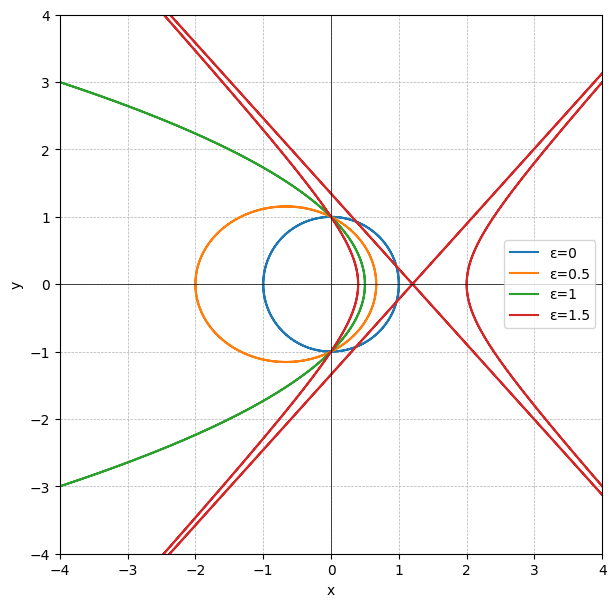

In [ ]:
def orbitas(alpha, epsilon, psi):  
    denominador = 1 + epsilon * math.cos(psi)
    if abs(denominador) < 1e-6:  # Evitar división por cero
        return None
    r = alpha / denominador
    return r   

# Definir rangos de valores
psi_vals = [i*0.01 for i in range(0, int(2 * math.pi * 200))]  
epsilon_vals = [ 0, 0.5, 1, 1.5]   
alpha = 1   
 

  
plt.figure(figsize=(7, 7))

for epsilon in epsilon_vals:
    r_vals = [orbitas(alpha, epsilon, psi) for psi in psi_vals]
    x_vals = [r * math.cos(psi) for r, psi in zip(r_vals, psi_vals) if r is not None]
    y_vals = [r * math.sin(psi) for r, psi in zip(r_vals, psi_vals) if r is not None]

    plt.plot(x_vals, y_vals, label=f"ε={epsilon}")

# Configuración de la gráfica cartesiana
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.axis([-4, 4, -4, 4])   
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [ ]:
import math
import matplotlib.pyplot as plt

class OrbitaParticula:
    def __init__(self, m, K, L, u0, v0, h=0.01, theta_max=2*math.pi):
        """Inicializa los parámetros físicos y numéricos"""
        self.m = m  # Masa de la partícula
        self.K = K  # Constante de la fuerza central
        self.L = L  # Momento angular
        self.u0 = u0  # Condición inicial de u
        self.v0 = v0  # Condición inicial de v
        self.h = h  # Tamaño de paso en RK4
        self.theta_max = theta_max  # Ángulo máximo de integración
        
        # Resolver la ecuación diferencial
        self.theta_vals, self.u_vals = self._runge_kutta()
    
    def _f1(self, theta, u, v):
        """ du/dtheta = v """
        return v

    def _f2(self, theta, u, v):
        """ dv/dtheta = m*K/L^2 - u """
        return (self.m * self.K) / (self.L ** 2) - u

    def _runge_kutta(self):
        """ Implementa el método de Runge-Kutta de 4º orden """
        theta, u, v = 0, self.u0, self.v0
        theta_vals, u_vals = [theta], [u]

        while theta < self.theta_max:
            k1_u = self.h * self._f1(theta, u, v)
            k1_v = self.h * self._f2(theta, u, v)

            k2_u = self.h * self._f1(theta + self.h/2, u + k1_u/2, v + k1_v/2)
            k2_v = self.h * self._f2(theta + self.h/2, u + k1_u/2, v + k1_v/2)

            k3_u = self.h * self._f1(theta + self.h/2, u + k2_u/2, v + k2_v/2)
            k3_v = self.h * self._f2(theta + self.h/2, u + k2_u/2, v + k2_v/2)

            k4_u = self.h * self._f1(theta + self.h, u + k3_u, v + k3_v)
            k4_v = self.h * self._f2(theta + self.h, u + k3_u, v + k3_v)

            u += (k1_u + 2*k2_u + 2*k3_u + k4_u) / 6
            v += (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6
            theta += self.h

            theta_vals.append(theta)
            u_vals.append(u)

        return theta_vals, u_vals

    @property
    def r_vals(self):
        """ Devuelve los valores de r = 1/u """
        return [1/u if u != 0 else float('inf') for u in self.u_vals]

    @property
    def x_vals(self):
        """ Devuelve las coordenadas x en cartesianas """
        return [r * math.cos(theta) for r, theta in zip(self.r_vals, self.theta_vals)]

    @property
    def y_vals(self):
        """ Devuelve las coordenadas y en cartesianas """
        return [r * math.sin(theta) for r, theta in zip(self.r_vals, self.theta_vals)]

    @property
    def orbita(self):
        """ Devuelve la trayectoria en formato (x, y) """
        return list(zip(self.x_vals, self.y_vals))

    @property
    def energia_total(self):
        """ Calcula la energía total de la partícula """
        # Aproximación de la derivada usando diferencias finitas (sin numpy)
        v_vals = [(self.r_vals[i+1] - self.r_vals[i]) / self.h for i in range(len(self.r_vals)-1)]
        v_vals.append(v_vals[-1])  # Mantener el mismo tamaño de lista

        energia = [(0.5 * self.m * v**2 - self.K / r) for v, r in zip(v_vals, self.r_vals)]
        return energia

    @property
    def periodo_orbital(self):
        """ Estima el período orbital (si la órbita es cerrada) """
        if self.r_vals:
            return self.theta_max / (2 * math.pi)  # Estimación aproximada
        return None

    def graficar_orbita(self):
        """ Genera la gráfica de la órbita """
        plt.figure(figsize=(6, 6))
        plt.plot(self.x_vals, self.y_vals, label="Órbita de la partícula")
        plt.scatter(0, 0, color='red', marker='o', label="Centro de fuerza")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Órbita de la partícula")
        plt.legend()
        plt.grid()
        plt.axis("equal")
        plt.show()


Valores de r: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Coordenadas x: [1.0, 0.9999500004166653, 0.9998000066665778, 0.9995500337489875, 0.9992001066609779, 0.9987502603949663, 0.9982005399352042, 0.9975510002532796, 0.9968017063026194, 0.9959527330119943]
Coordenadas y: [0.0, 0.009999833334166664, 0.01999866669333308, 0.02999550020249566, 0.03998933418663416, 0.04997916927067833, 0.0599640064794446, 0.06994284733753277, 0.0799146939691727, 0.08987854919801104]
Energía total en algunos puntos: [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
Período orbital estimado: 2.0


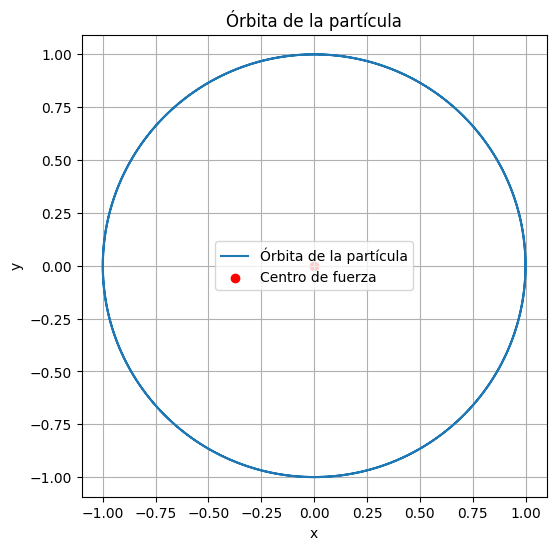

In [ ]:


# Crear una instancia de la clase
orbita = OrbitaParticula(m=1, K=1, L=1, u0=1, v0=0, h=0.01, theta_max=2*math.pi*2)

# Acceder a los valores calculados
print("Valores de r:", orbita.r_vals[:10])  # Primeros 10 valores de r
print("Coordenadas x:", orbita.x_vals[:10])  # Primeros 10 valores de x
print("Coordenadas y:", orbita.y_vals[:10])  # Primeros 10 valores de y
print("Energía total en algunos puntos:", orbita.energia_total[:10])  # Energía en 10 puntos
print("Período orbital estimado:", orbita.periodo_orbital)

# Graficar la órbita
orbita.graficar_orbita()